# 머신러닝 회귀모델 실습

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error

## 데이터 로딩 및 단위 변경

In [2]:
# read weight-height dataset
data = "datas_ml/weight-height.csv"
wh_df = pd.read_csv(data)

In [3]:
wh_df.head()

,Gender,Height,Weight
0,Male,73.847017,241.893563
1,Male,68.781904,162.310473
2,Male,74.110105,212.740856
3,Male,71.730978,220.042470
4,Male,69.881796,206.349801


### [문제해결] 컬럼 단위를 우리에게 익숙한 값으로 변경하기
- 키: inch -> cm, 1inch = 2.54cm
- 몸무게: lb -> kg, 1lb = 0.4563kg

In [4]:
wh_df["Height"] = wh_df["Height"]*2.54
wh_df["Weight"] = wh_df["Weight"]*0.4563
wh_df.head()

,Gender,Height,Weight
0,Male,187.571423,110.376033
1,Male,174.706036,74.062269
2,Male,188.239668,97.073652
3,Male,182.196685,100.405379
4,Male,177.499761,94.157414


In [5]:
wh_df.shape

(10000, 3)

## 데이터 탐색

In [6]:
wh_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 3 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   Gender  10000 non-null  object 
 1   Height  10000 non-null  float64
 2   Weight  10000 non-null  float64
dtypes: float64(2), object(1)
memory usage: 234.5+ KB


In [7]:
wh_df.describe()

,Height,Weight
count,10000.000000,10000.000000
mean,168.573602,73.665235
std,9.772721,14.651081
min,137.828359,29.522668
25%,161.304276,61.973777
50%,168.447898,73.561459
75%,175.702625,85.405454
max,200.656806,123.196299


In [8]:
wh_df['Gender'].describe()

count     10000
unique        2
top        Male
freq       5000
Name: Gender, dtype: object

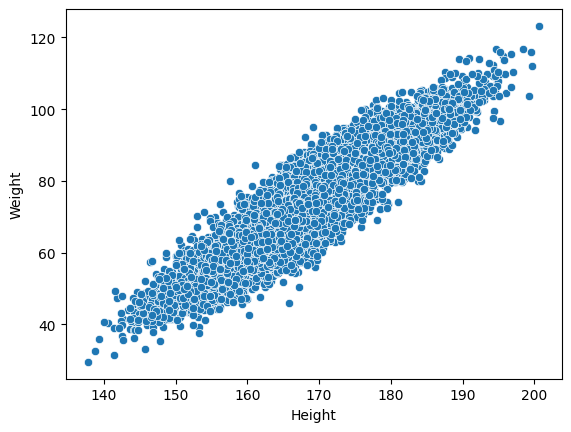

In [42]:
sns.scatterplot(data=wh_df, x='Height', y='Weight')
plt.show()

# 키에 따른 몸무게 예측
## 학습, 테스트 데이터 준비
- Feature(x)와 label(y) 데이터 분리

In [43]:
x=wh_df['Height']
y=wh_df['Weight']

In [11]:
y[:5]

0    110.376033
1     74.062269
2     97.073652
3    100.405379
4     94.157414
Name: Weight, dtype: float64

## 80%는 트레이닝 데이터, 20%는 테스트 데이터로 나누기
- random_seed 값 주기
- stratify=y 설정은
    - target이 classification인 경우
    - feature가 2개이상 있을 때 사용

In [44]:
# 학습, 테스트 데이터셋으로 분할
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.2, random_state=10)

In [14]:
x_train.shape, y_train.shape, x_test.shape, y_test.shape

((8000,), (8000,), (2000,), (2000,))

## 회귀모델 학습하기
- 선형회귀(Linear Regression)

In [15]:
# x_train 데이터가 1D이면 오류 발생함
model_lr = LinearRegression()

In [16]:
model_lr

,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


In [17]:
# x는 2차원이어야 함
x_train_2d = x_train.values.reshape(-1, 1)
x_train_2d

array([[158.38424815],
       [150.90929264],
       [163.96639183],
       ...,
       [172.08583788],
       [167.17562084],
       [174.96463993]], shape=(8000, 1))

In [18]:
# 모델핛습
model_lr.fit(x_train_2d, y_train)

,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


In [ ]:
# 회귀선 기울기 확인(a)
model_lr.coef_

array([1.38648312])

In [ ]:
# 회귀선의 절편(b)
model_lr.intercept_

np.float64(-160.11720767437617)

## 학습 모델 테스트

In [21]:
# 테스트 데이터에 대한 예측을 수행
# 독립변수 x_test도 2D로 바꿔야 함
x_test_2d = x_test.values.reshape(-1, 1)
x_test_2d

array([[173.53649028],
       [164.22298414],
       [188.04787828],
       ...,
       [171.59270539],
       [162.35978704],
       [158.54282215]], shape=(2000, 1))

In [22]:
# 테스트 데이터를 모델에 입력해서 테스트함 -> y_hat(예측값)
y_pred = model_lr.predict(x_test_2d)

In [ ]:
# 테스트 데이터의 예측값
y_pred

array([ 80.48820744,  67.57518835, 100.608002  , ...,  77.79318249,
        64.99189701,  59.69973961], shape=(2000,))

In [ ]:
# 실제값(관측한 테스트의 y값)
y_test

937     94.192251
9355    67.971504
2293    99.389349
192     93.037587
8675    58.119952
          ...    
5624    55.992292
6005    55.485244
987     91.615773
6152    64.285294
2092    74.167774
Name: Weight, Length: 2000, dtype: float64

## 모델 성능 평가하기
[] 회귀 모델의 성능 평가
- MSE(Mean Squared Error)를 측정하기
- RMSE(Root Mean Squared Error)를 측정하기 <- 평균 오차

In [26]:
# MSE (Mean Squared Error)
MSE = mean_squared_error(y_test, y_pred)

# RMSE (Root Mean Squared Error)
RMSE = np.sqrt(MSE)

print('MSE :', MSE)
print('RMSE :', RMSE)

MSE : 31.729201319729608
RMSE : 5.632867948010996


## ML 모델 일반화
### [문제해결] 내 몸무게 예측해보기
- [힌트] x_train 또는 x_test와 같은 shape으로 입력
키 165cm -> 몸무게 ?:[[165]]  
- 방법1:  
    lr.predict([[165]])
- 방법2:  
    y_pred2 = lr.predict(np.array([177,185]).reshape(-1,1))  
    y_pred2  
- 방법3:  
    my_height1 = pd.Series(172)  
    type(my_height1)  
    model_lr.predict(my_height1.values.reshape(-1,1))      

In [28]:
a = model_lr.coef_
b = model_lr.intercept_
# y_pred = a * x + b
y = a * 165 + b
y

array([68.65250773])

In [54]:
my_data = pd.Series([165])
model_lr.predict(my_data.values.reshape(-1, 1))

array([68.65250773])

## 예측 결과 시각화

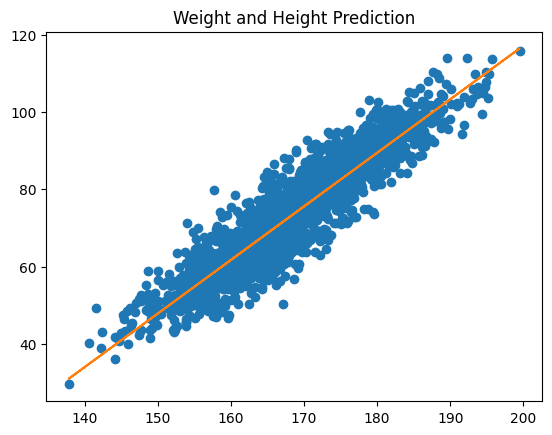

In [29]:
plt.plot(x_test, y_test, 'o')
plt.plot(x_test, y_pred)
plt.title('Weight and Height Prediction')
plt.show()

## 키와 성별에 따른 몸무게 예측하기
- feature 갯수 2개로 학습하기
- Gender, height 데이터로 linear regression 모델 만들기
- Gender는 범주형 데이터임: One Hot Encoding으로 변환하기

In [31]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error

## 데이터 로딩 및 가공

In [33]:
# read weight-height dataset
data = "datas_ml/weight-height.csv"
gwh_df = pd.read_csv(data)
gwh_df.head()

,Gender,Height,Weight
0,Male,73.847017,241.893563
1,Male,68.781904,162.310473
2,Male,74.110105,212.740856
3,Male,71.730978,220.042470
4,Male,69.881796,206.349801


In [34]:
# 인치, 파운드 -> cm,kg으로 변환
gwh_df['Height'] = gwh_df['Height'] * 2.54
gwh_df['Weight'] = gwh_df['Weight'] * 0.4563
gwh_df.head()

,Gender,Height,Weight
0,Male,187.571423,110.376033
1,Male,174.706036,74.062269
2,Male,188.239668,97.073652
3,Male,182.196685,100.405379
4,Male,177.499761,94.157414


<Figure size 1000x600 with 0 Axes>

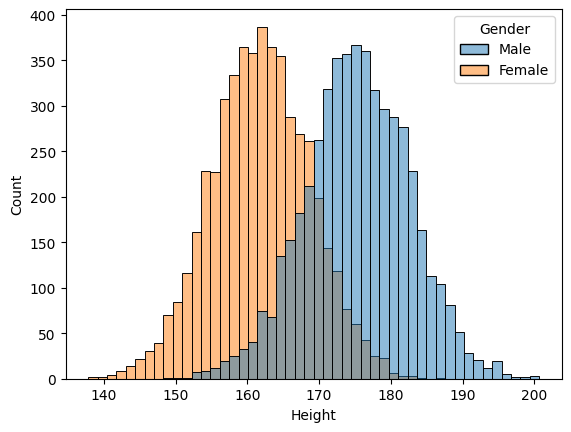

<Figure size 1000x600 with 0 Axes>

In [35]:
# feature distribution
sns.histplot(data=gwh_df, x='Height', hue='Gender')
plt.figure(figsize=(10,6))

## ML을 위한 feature Engineering
- 범주형 데이터 숫자로 변환: One Hot Encoding

In [36]:
gwh_df['Gender'].value_counts()

Gender
Male      5000
Female    5000
Name: count, dtype: int64

In [37]:
# Gender 컬럼을 숫자로 변환 (레이블 인코딩: 문자형 데이터 -> 숫자형 데이터로 변환)
gwh_df['Gender']=gwh_df['Gender'].map({'Male': 0, 'Female': 1})
gwh_df.head()

,Gender,Height,Weight
0,0,187.571423,110.376033
1,0,174.706036,74.062269
2,0,188.239668,97.073652
3,0,182.196685,100.405379
4,0,177.499761,94.157414


### 학습, 테스트 데이터 준비

In [40]:
X=gwh_df.drop(columns = 'Weight')
y=gwh_df['Weight']

In [45]:
X.head()

,Gender,Height
0,0,187.571423
1,0,174.706036
2,0,188.239668
3,0,182.196685
4,0,177.499761


In [47]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=10)

In [48]:
X_train

,Gender,Height
7496,1,158.384248
7694,1,150.909293
9248,1,163.966392
2470,0,164.883928
4392,0,177.657963
...,...,...
9372,1,162.762175
7291,1,167.778361
1344,0,172.085838
7293,1,167.175621


## 회귀 모델 학습

In [49]:
model_lr2 = LinearRegression()
model_lr2.fit(X_train, y_train)

,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


## 테스트 및 성능 평가

In [50]:
y_pred = model_lr2.predict(X_test)
y_pred

array([83.34626959, 64.56600829, 98.93675001, ..., 81.25794142,
       62.56426057, 67.23764583], shape=(2000,))

In [51]:
X_test.columns

Index(['Gender', 'Height'], dtype='object')

### [문제해결] MSE, RMSE 구하기

In [53]:
# MSE (Mean Squared Error)를 측정하기
MSE = mean_squared_error(y_test, y_pred)

# RMSE (Root Mean Squared Error)를 측정하기
RMSE = np.sqrt(MSE)

print('MSE :', MSE)
print('RMSE :', RMSE)

MSE : 20.78688216421087
RMSE : 4.5592633356948


## ML 모델 일반화
### [문제해결] 키와 성별 정보로 일반 데이터를 구성하여 예측하기

In [63]:
my_test = [[1, 165]]
my_test

[[1, 165]]

In [64]:
model_lr2.predict(my_test)

c:\Users\Admin\miniconda3\envs\eda_env\lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(


array([65.40080443])

In [65]:
X_test[:5]

,Gender,Height
937,0,173.536490
9355,1,164.222984
2293,0,188.047878
192,0,177.111164
8675,1,164.033023


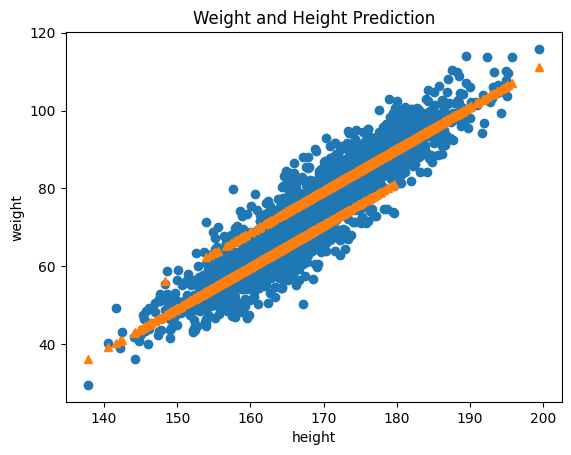

In [66]:
plt.plot(X_test.loc[:,'Height'], y_test, 'o')  # 실제값 표시
plt.plot(X_test.loc[:,'Height'], y_pred, '^')  # 예측값 표시
plt.title('Weight and Height Prediction')
plt.xlabel('height')
plt.ylabel('weight')
plt.show()